In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

from pangya_physics import (
    CLUBS,
    Ball,
    PangyaSimulator,
    Wind,
)

from pangya_physics.solver import create_initial_velocity

In [2]:
def simulate_trajectory(
    club_name,
    power_percent=1.0,
    wind_speed=0,
    wind_degree=0,
    max_steps=5000,
):
    club = CLUBS[club_name]

    ball = Ball(
        velocity=create_initial_velocity(
            club=club,
            power_percent=power_percent,
        )
    )

    simulator = PangyaSimulator(
        ball=ball,
        club=club,
        wind=Wind(speed=wind_speed, degree=wind_degree),
    )

    trajectory = []

    for _ in range(max_steps):
        simulator.step()

        trajectory.append({
            "club": club_name,
            "step": simulator.ball.count,
            "x": simulator.ball.position.x,
            "y": simulator.ball.position.y,
            "z": simulator.ball.position.z,
        })

        if simulator.ball.position.y < 0 and simulator.ball.count > 10:
            break

    return pd.DataFrame(trajectory)

In [3]:
selected_clubs = ["1W", "3W", "5I", "9I", "PW", "SW"]

trajectories = []

for club_name in selected_clubs:
    trajectories.append(
        simulate_trajectory(
            club_name=club_name,
            power_percent=1.0,
        )
    )

df_trajectory = pd.concat(trajectories, ignore_index=True)

df_trajectory.head()

,club,step,x,y,z
0,1W,1,0.0,0.799163,4.610076
1,1W,2,0.0,1.578094,9.182579
2,1W,3,0.0,2.337014,13.718138
3,1W,4,0.0,3.076136,18.217366
4,1W,5,0.0,3.795670,22.680861


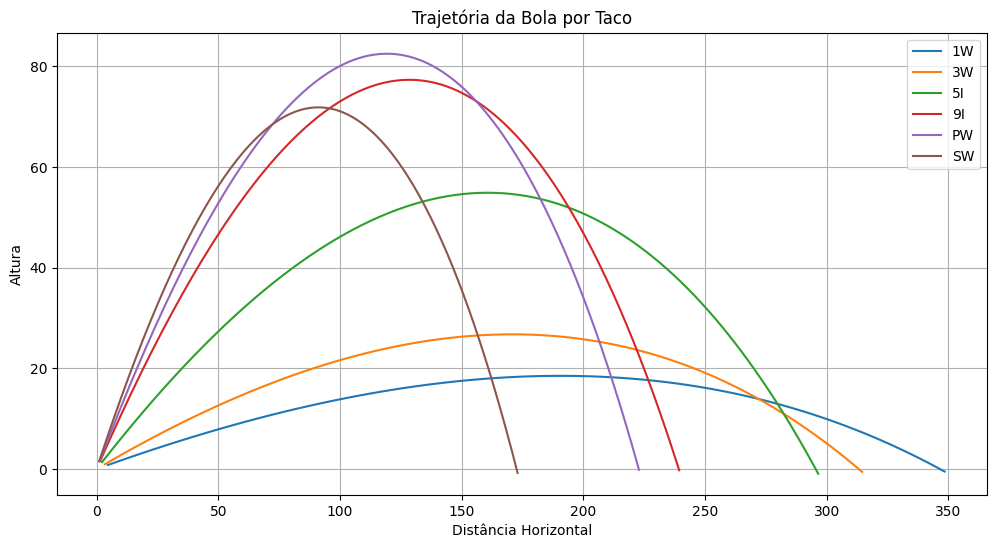

In [4]:
plt.figure(figsize=(12, 6))

for club_name in selected_clubs:
    subset = df_trajectory[df_trajectory["club"] == club_name]

    plt.plot(
        subset["z"],
        subset["y"],
        label=club_name,
    )

plt.xlabel("Distância Horizontal")
plt.ylabel("Altura")
plt.title("Trajetória da Bola por Taco")
plt.grid(True)
plt.legend()
plt.show()

In [5]:
trajectory_summary = (
    df_trajectory
    .groupby("club")
    .agg(
        final_distance=("z", "max"),
        max_height=("y", "max"),
        flight_steps=("step", "max"),
    )
    .reset_index()
    .sort_values("final_distance", ascending=False)
)

trajectory_summary

,club,final_distance,max_height,flight_steps
0,1W,348.470713,18.513927,104
1,3W,314.588992,26.756576,125
2,5I,296.524395,54.889102,179
3,9I,239.391638,77.322153,212
4,PW,222.884634,82.505808,219
5,SW,172.972305,71.850741,205


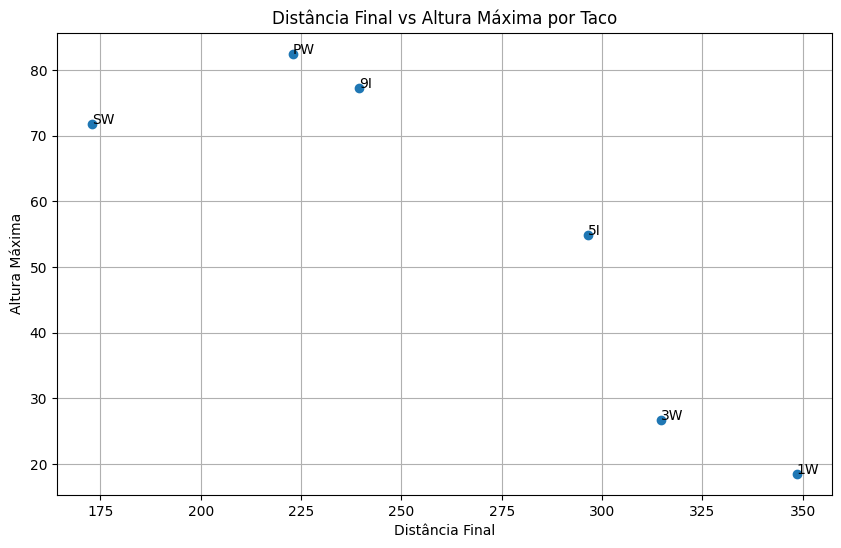

In [6]:
plt.figure(figsize=(10, 6))

plt.scatter(
    trajectory_summary["final_distance"],
    trajectory_summary["max_height"],
)

for _, row in trajectory_summary.iterrows():
    plt.text(
        row["final_distance"],
        row["max_height"],
        row["club"],
    )

plt.xlabel("Distância Final")
plt.ylabel("Altura Máxima")
plt.title("Distância Final vs Altura Máxima por Taco")
plt.grid(True)
plt.show()

In [7]:
wind_trajectories = []

for club_name in ["1W", "5I", "PW"]:
    wind_trajectories.append(
        simulate_trajectory(
            club_name=club_name,
            power_percent=1.0,
            wind_speed=5,
            wind_degree=90,
        )
    )

df_wind_trajectory = pd.concat(wind_trajectories, ignore_index=True)

df_wind_trajectory.head()

,club,step,x,y,z
0,1W,1,-0.000871,0.799163,4.610076
1,1W,2,-0.002606,1.578094,9.182579
2,1W,3,-0.005197,2.337014,13.718138
3,1W,4,-0.008639,3.076136,18.217366
4,1W,5,-0.012925,3.795670,22.680861


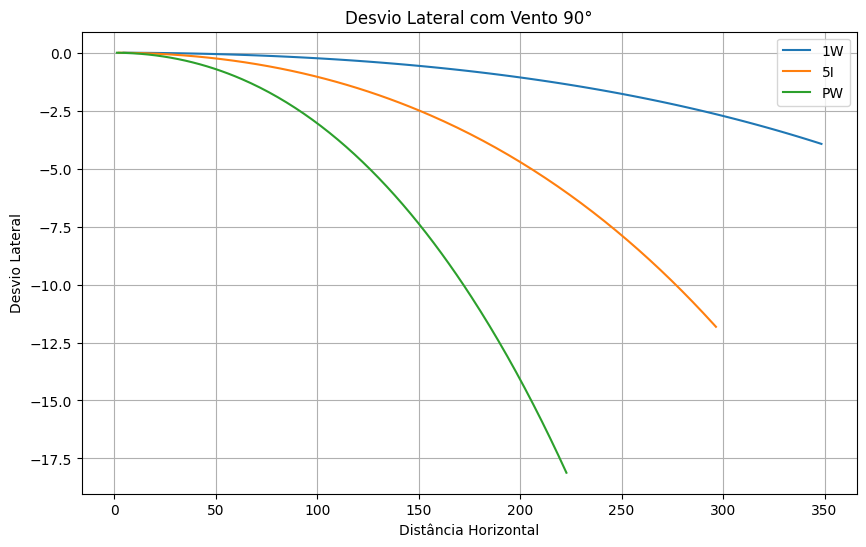

In [8]:
plt.figure(figsize=(10, 6))

for club_name in ["1W", "5I", "PW"]:
    subset = df_wind_trajectory[df_wind_trajectory["club"] == club_name]

    plt.plot(
        subset["z"],
        subset["x"],
        label=club_name,
    )

plt.xlabel("Distância Horizontal")
plt.ylabel("Desvio Lateral")
plt.title("Desvio Lateral com Vento 90°")
plt.grid(True)
plt.legend()
plt.show()